# Analyse Exploratoire des Tickets de Support

Notebook simple pour débutants

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv('../data/raw/dataset.csv')

print(f"Nombre de tickets: {len(df)}")
print(f"Colonnes: {list(df.columns)}")

Nombre de tickets: 20000
Colonnes: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


## 2. Distribution des types de tickets

Distribution des types de tickets:
type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64



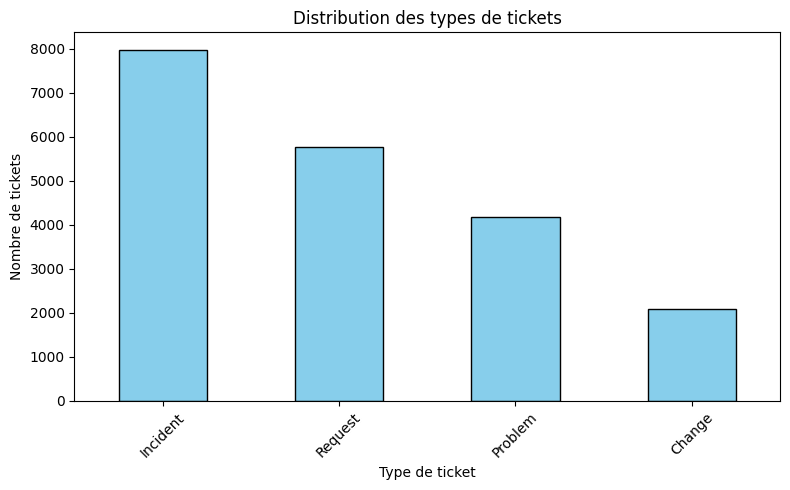


Pourcentages:
  Incident: 39.9%
  Request: 28.8%
  Problem: 20.9%
  Change: 10.4%


In [2]:
# Compter les tickets par type
type_counts = df['type'].value_counts()

print("Distribution des types de tickets:")
print(type_counts)
print()

# Visualisation
plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution des types de tickets')
plt.xlabel('Type de ticket')
plt.ylabel('Nombre de tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pourcentages
print("\nPourcentages:")
for ticket_type, count in type_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {ticket_type}: {pct:.1f}%")

## 3. Longueur des emails

Statistiques de longueur des emails:
  Moyenne: 394 caractères
  Médiane: 357 caractères
  Minimum: 0 caractères
  Maximum: 2259 caractères



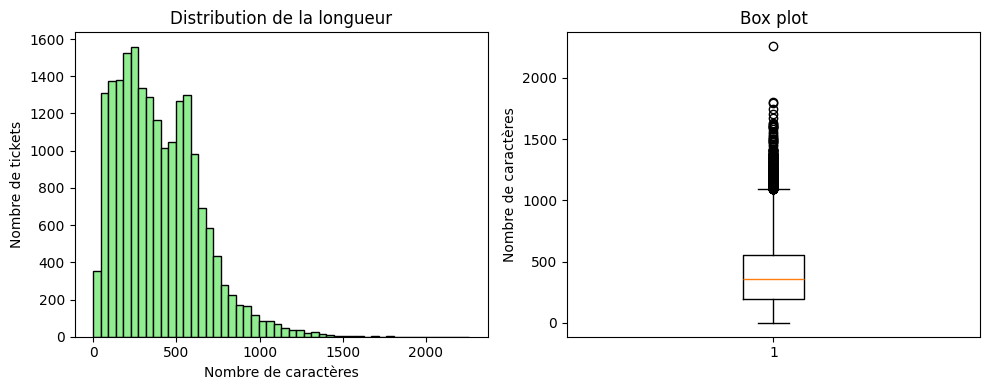

In [3]:
# Calculer la longueur de chaque email
# Remplacer les valeurs manquantes par une chaîne vide
df['body_length'] = df['body'].fillna('').str.len()

# Statistiques
print("Statistiques de longueur des emails:")
print(f"  Moyenne: {df['body_length'].mean():.0f} caractères")
print(f"  Médiane: {df['body_length'].median():.0f} caractères")
print(f"  Minimum: {df['body_length'].min()} caractères")
print(f"  Maximum: {df['body_length'].max()} caractères")
print()

# Visualisation
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['body_length'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution de la longueur')
plt.xlabel('Nombre de caractères')
plt.ylabel('Nombre de tickets')

plt.subplot(1, 2, 2)
plt.boxplot(df['body_length'])
plt.title('Box plot')
plt.ylabel('Nombre de caractères')

plt.tight_layout()
plt.show()

## 4. Fusion des champs texte (subject + body)

In [5]:
# Remplacer les NaN par des chaînes vides
df['subject_clean'] = df['subject'].fillna('')
df['body_clean'] = df['body'].fillna('')

# Fusionner subject et body
df['text_combined'] = df['subject_clean'] + ' ' + df['body_clean']

df.to_csv("../data/processed/clean1.csv", index=False)

# Exemples
print("Exemples de fusion:")
print("="*70)
for i in range(3):
    print(f"\nExemple {i+1}:")
    print(f"  Subject: {df['subject_clean'].iloc[i]}")
    print(f"  Body: {df['body_clean'].iloc[i][:80]}...")
    print(f"  Combined: {df['text_combined'].iloc[i][:120]}...")

# Longueur du texte combiné
df['text_combined_length'] = df['text_combined'].str.len()
print(f"\nLongueur moyenne du texte combiné: {df['text_combined_length'].mean():.0f} caractères")

Exemples de fusion:

Exemple 1:
  Subject: Unvorhergesehener Absturz der Datenanalyse-Plattform
  Body: Die Datenanalyse-Plattform brach unerwartet ab, da die Speicheroberfläche zu ger...
  Combined: Unvorhergesehener Absturz der Datenanalyse-Plattform Die Datenanalyse-Plattform brach unerwartet ab, da die Speicherober...

Exemple 2:
  Subject: Customer Support Inquiry
  Body: Seeking information on digital strategies that can aid in brand growth and detai...
  Combined: Customer Support Inquiry Seeking information on digital strategies that can aid in brand growth and details on the avail...

Exemple 3:
  Subject: Data Analytics for Investment
  Body: I am contacting you to request information on data analytics tools that can be u...
  Combined: Data Analytics for Investment I am contacting you to request information on data analytics tools that can be utilized wi...

Longueur moyenne du texte combiné: 437 caractères
